# Autoencoder Baseline -- One-Class Classification

## Ziel

Wir zeigen dem Modell **nur gute Ruderschlaege**. Danach entscheidet es:
> Ist dieser neue Schlag aehnlich genug zu dem, was ich gelernt habe?

Das ist ein **One-Class Classification** Problem (auch: Anomalieerkennung).
- Klasse 0 (Normal): guter Schlag
- Alles andere: schlechter Schlag (Anomalie)

---

## Was ist ein Autoencoder?

Ein Autoencoder ist ein neuronales Netz mit zwei Teilen:

```
Input (Sequenz) --> [ENCODER] --> Bottleneck --> [DECODER] --> Rekonstruktion
```

- **Encoder**: komprimiert die Eingabe auf eine kleine Repraesentation (Bottleneck)
- **Decoder**: versucht, die Eingabe aus dem Bottleneck zu rekonstruieren
- **Verlust**: Mean Squared Error zwischen Input und Rekonstruktion

Das Modell lernt, **gute Schlaege gut zu rekonstruieren**. Fuer schlechte Schlaege ist der Rekonstruktionsfehler hoch -- das ist das Erkennungssignal.

---

## LSTM vs. Conv1D

| | LSTM | Conv1D |
|---|---|---|
| **Was es tut** | Merkt sich vergangene Schritte (Gedaechtnis) | Sucht lokale Muster im Zeitfenster |
| **Gut fuer** | Rhythmus, Langzeit-Abhaengigkeiten | Kurze charakteristische Bewegungsmuster |
| **Geschwindigkeit** | Langsamer | Schneller |
| **Wir waehlen** | Ja | Nein |

**LSTM** ist besser geeignet, weil der Gesamtrhythmus (Vorlage -> Antrieb -> Endzug) ueber die ganze Sequenz wichtig ist.


In [83]:
!pip install tensorflow


[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'requirements.txt').exists()
)
NORM_DIR = PROJECT_ROOT / '1_DatasetCharacteristics' / 'landmarks' / 'normalized'

print('TensorFlow:', tf.__version__) 
print('Project root:', PROJECT_ROOT)

TensorFlow: 2.21.0
Project root: /Users/clarabrilke/ML projects/ML-project


In [85]:
EXCLUDE_COLS = {'phase', 'GOOD', 'BAD'}

def resample_seq(seq, target_len):
    """Interpoliert eine Sequenz variabler Laenge auf target_len Frames."""
    x_old = np.linspace(0, 1, len(seq))
    x_new = np.linspace(0, 1, target_len)
    return interp1d(x_old, seq, axis=0)(x_new)

def load_strokes_for_video(video_stem):
    lm_path     = NORM_DIR / f'{video_stem}-landmarks-norm_10fps.csv'
    stroke_path = NORM_DIR / f'{video_stem}-strokes.csv'
    landmarks   = pd.read_csv(lm_path)
    strokes     = pd.read_csv(stroke_path)
    feature_cols = [c for c in landmarks.columns if c not in EXCLUDE_COLS]
    X = landmarks[feature_cols].values

    # strokes.csv speichert Frame-Nummern aus dem Originalvideo (~30fps).
    # Die landmarks-Datei ist auf 10fps heruntergesampelt (~Faktor 3).
    # Deshalb muessen die Indizes durch den fps-Faktor geteilt werden.
    fps_ratio = max(1, round(strokes['endzug_end'].max() / len(landmarks)))

    seqs = []
    for _, row in strokes.iterrows():
        start = int(row['endzug_start'] / fps_ratio)
        end   = int(row['endzug_end']   / fps_ratio)
        seq   = X[start:end]
        if len(seq) >= 10:
            seqs.append(seq)
    return seqs, feature_cols, fps_ratio

# --- Alle Stroke-Dateien automatisch einlesen ---
stroke_files = sorted(NORM_DIR.glob('*-strokes.csv'))
stroke_files = [f for f in stroke_files if not f.stem.startswith('sim')]

print(f'Gefundene Videos: {len(stroke_files)}')
for f in stroke_files:
    label = 'BAD ' if 'BAD' in f.stem.upper() else 'GOOD'
    print(f'  [{label}]  {f.stem}')

# TARGET_LEN = Median der Schlaglaengen (in 10fps-Frames) ueber alle Videos
all_lengths = []
for sf in stroke_files:
    lm = pd.read_csv(NORM_DIR / f'{sf.stem.replace("-strokes", "")}-landmarks-norm_10fps.csv')
    st = pd.read_csv(sf)
    fps_ratio = max(1, round(st['endzug_end'].max() / len(lm)))
    lengths = ((st['endzug_end'] - st['endzug_start']) / fps_ratio).round().astype(int)
    all_lengths.extend(lengths.tolist())

TARGET_LEN = int(np.median(all_lengths))
print(f'\nSchlaglaengen (10fps) -- min: {min(all_lengths)}  median: {TARGET_LEN}  max: {max(all_lengths)}')
print(f'TARGET_LEN = {TARGET_LEN} Frames')

# --- Sequenzen laden und resamplen ---
good_seqs, bad_seqs = [], []
feature_cols = None

for sf in stroke_files:
    video_stem = sf.stem.replace('-strokes', '')
    seqs, fcols, ratio = load_strokes_for_video(video_stem)
    if feature_cols is None:
        feature_cols = fcols
    resampled = [resample_seq(s, TARGET_LEN) for s in seqs]
    if 'BAD' in video_stem.upper():
        bad_seqs.extend(resampled)
        print(f'  {video_stem}: {len(seqs)} Schlaege geladen (fps_ratio={ratio})')
    else:
        good_seqs.extend(resampled)
        print(f'  {video_stem}: {len(seqs)} Schlaege geladen (fps_ratio={ratio})')

X_good_seq = np.array(good_seqs)
X_bad_seq  = np.array(bad_seqs)

print(f'\nGute Schlaege:      {X_good_seq.shape}  (n_sequenzen, frames, features)')
print(f'Schlechte Schlaege: {X_bad_seq.shape}')

Gefundene Videos: 5
  [BAD ]  cla-BAD-strokes
  [GOOD]  cla-GOOD-fast-strokes
  [GOOD]  cla-GOOD-slow-strokes
  [GOOD]  mar-GOOD-fast-strokes
  [GOOD]  mar-GOOD-slow-strokes

Schlaglaengen (10fps) -- min: 18  median: 24  max: 30
TARGET_LEN = 24 Frames
  cla-BAD: 20 Schlaege geladen (fps_ratio=3)
  cla-GOOD-fast: 87 Schlaege geladen (fps_ratio=3)
  cla-GOOD-slow: 68 Schlaege geladen (fps_ratio=3)
  mar-GOOD-fast: 61 Schlaege geladen (fps_ratio=3)
  mar-GOOD-slow: 50 Schlaege geladen (fps_ratio=3)

Gute Schlaege:      (266, 24, 66)  (n_sequenzen, frames, features)
Schlechte Schlaege: (20, 24, 66)


## Normalisierung

Beide Datensaetze wurden durch die gleiche koerperrelative Mediapipe-Normalisierung verarbeitet.
Ein zusaetzlicher StandardScaler ist nicht mehr noetig -- die Skalen sind bereits vergleichbar.


In [86]:
# Daten sind bereits durch Mediapipe-Normalisierung skaliert -- kein StandardScaler noetig.
print('Gute Schlaege   -- Mittelwert:', X_good_seq.mean().round(4), 'Std:', X_good_seq.std().round(4))
print('Schlechte Schlaege -- Mittelwert:', X_bad_seq.mean().round(4), 'Std:', X_bad_seq.std().round(4))

Gute Schlaege   -- Mittelwert: -0.458 Std: 0.6379
Schlechte Schlaege -- Mittelwert: -0.5012 Std: 0.6328


## Segmentierung an echten Schlaggrenzen

Statt eines gleitenden Fensters wird jeder Schlag exakt an seinen echten Grenzen aus den Stroke-Dateien ausgeschnitten:

```
endzug_start --> endzug_end   = ein vollstaendiger Schlag
```

Da Schlaege unterschiedlich lang sind (z.B. 67–78 Frames), wird jede Sequenz per linearer Interpolation auf **TARGET_LEN** Frames resamplet. Das hat zwei Vorteile:
- Das LSTM bekommt immer gleichlange Eingaben
- Schnelle und langsame Schlaege sind direkt vergleichbar (Geschwindigkeit wird herausnormalisiert)

Neue Videos mit Stroke-Dateien im `normalized/`-Ordner werden **automatisch** erkannt.

In [87]:
# Sequenzen wurden bereits in cell-02 geladen -- hier nur zur Uebersicht
print(f'Gute Sequenzen:      {X_good_seq.shape}  (n_sequenzen, frames, features)')
print(f'Schlechte Sequenzen: {X_bad_seq.shape}')

Gute Sequenzen:      (266, 24, 66)  (n_sequenzen, frames, features)
Schlechte Sequenzen: (20, 24, 66)


In [88]:
# Train / Validation Split -- nur gute Sequenzen
# Kein shuffle: zeitliche Reihenfolge erhalten
n_total = len(X_good_seq)
n_train = int(n_total * 0.8)

X_train = X_good_seq[:n_train]
X_val   = X_good_seq[n_train:]

print(f'Training:   {X_train.shape[0]} Sequenzen')
print(f'Validation: {X_val.shape[0]} Sequenzen')
print(f'Schlechte (nur Evaluation): {X_bad_seq.shape[0]} Sequenzen')


Training:   212 Sequenzen
Validation: 54 Sequenzen
Schlechte (nur Evaluation): 20 Sequenzen


## LSTM Autoencoder -- Architektur

```
Input: (24 Frames x 66 Features)
        |
  LSTM(128)         <-- verarbeitet die Sequenz, Ausgabe nur letzter Schritt
        |
  Dense(32)         <-- Bottleneck: komprimierte Repraesentation des Schlags
        |
  RepeatVector(24)  <-- dupliziert den Bottleneck fuer jeden Zeitschritt
        |
  LSTM(128, return_sequences=True)  <-- rekonstruiert die Sequenz
        |
  TimeDistributed(Dense(66))  <-- ein Output-Vektor pro Zeitschritt
        |
Output: (24 Frames x 66 Features) -- Rekonstruktion
```

**Loss**: MSE zwischen Input und Rekonstruktion.  
**Anomalie-Score**: mittlerer MSE ueber alle Zeitschritte einer Sequenz.


In [89]:
n_timesteps = TARGET_LEN
n_features  = X_train.shape[2]
LATENT_DIM  = 32

def build_lstm_autoencoder(timesteps, features, latent_dim):
    inputs = keras.Input(shape=(timesteps, features), name='input')

    # Encoder
    x = layers.LSTM(128, return_sequences=False, name='encoder_lstm')(inputs)
    bottleneck = layers.Dense(latent_dim, activation='relu', name='bottleneck')(x)

    # Decoder
    x = layers.RepeatVector(timesteps, name='repeat')(bottleneck)
    x = layers.LSTM(128, return_sequences=True, name='decoder_lstm')(x)
    outputs = layers.TimeDistributed(layers.Dense(features), name='output')(x)

    return keras.Model(inputs, outputs, name='LSTM_Autoencoder')

model = build_lstm_autoencoder(n_timesteps, n_features, LATENT_DIM)
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 66)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ (None, 128)            │        99,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm (LSTM)             │ (None, 24, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 24, 66)         │         8,514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,914 (761.38 KB)

 Trainable params: 194,914 (761.38 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
EPOCHS     = 50
BATCH_SIZE = 32

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,            # Autoencoder: Input = Target
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.4843 - val_loss: 0.2758
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1711 - val_loss: 0.1156
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0859 - val_loss: 0.0961
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0769 - val_loss: 0.0889
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0672 - val_loss: 0.0815
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0622 - val_loss: 0.0784
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0591 - val_loss: 0.0740
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0553 - val_loss: 0.0696
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0520 - val_loss: 0.0655
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0489 - val_loss: 0.0623
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0467 - val_loss: 0.0602
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0454 - val_loss: 0.0590
E

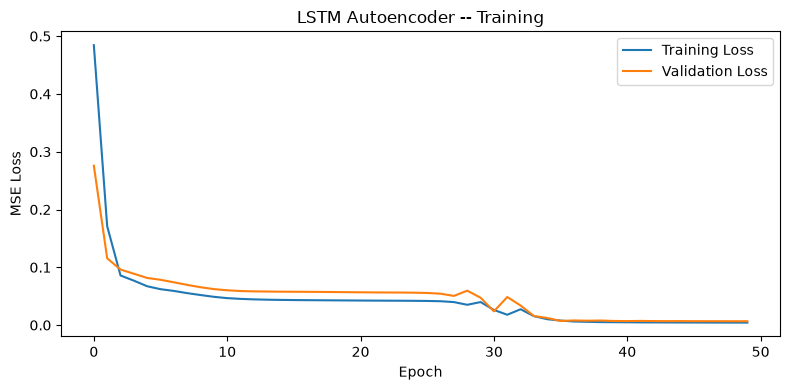

In [91]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Autoencoder -- Training')
ax.legend()
plt.tight_layout()
plt.show()


## Schwellenwert (Threshold)

Wir berechnen den Rekonstruktionsfehler (MSE) fuer alle Trainingssequenzen.
Als Schwellenwert waehlen wir das **95. Perzentil** der Trainings-Fehler:

> Sequenzen mit MSE > Threshold --> **schlechter Schlag**

Der Threshold kann angepasst werden (z.B. 99. Perzentil = strenger, weniger False Positives).


In [92]:
def reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=(1, 2))

train_errors = reconstruction_error(model, X_train)
val_errors   = reconstruction_error(model, X_val)
bad_errors   = reconstruction_error(model, X_bad_seq)

THRESHOLD_PERCENTILE = 99
threshold = np.percentile(train_errors, THRESHOLD_PERCENTILE)

print(f'Threshold ({THRESHOLD_PERCENTILE}. Perzentil der Trainingsfehler): {threshold:.6f}')
print(f'Mittlerer Fehler -- Training:   {train_errors.mean():.6f}')
print(f'Mittlerer Fehler -- Validation: {val_errors.mean():.6f}')
print(f'Mittlerer Fehler -- Schlechte:  {bad_errors.mean():.6f}')


Threshold (99. Perzentil der Trainingsfehler): 0.011678
Mittlerer Fehler -- Training:   0.004234
Mittlerer Fehler -- Validation: 0.006686
Mittlerer Fehler -- Schlechte:  0.024339


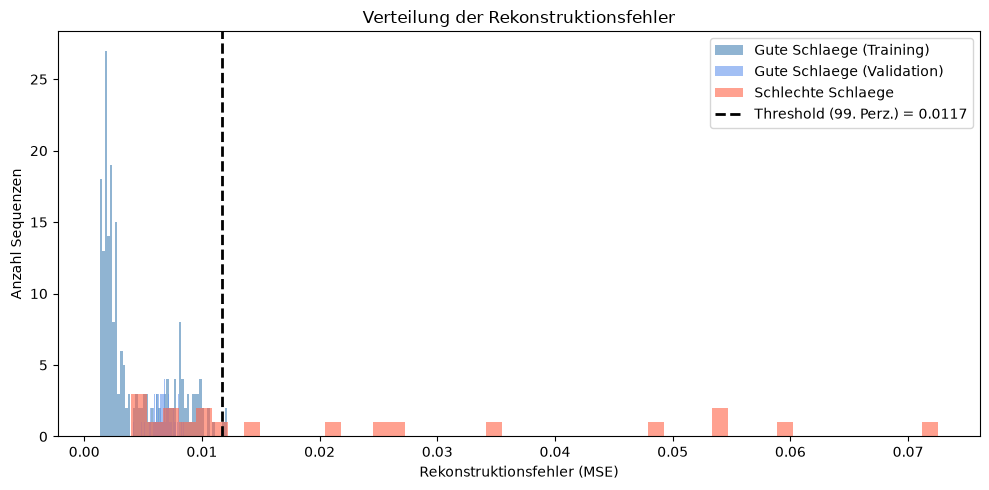

In [93]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_errors, bins=50, alpha=0.6, label='Gute Schlaege (Training)',  color='steelblue')
ax.hist(val_errors,   bins=50, alpha=0.6, label='Gute Schlaege (Validation)', color='cornflowerblue')
ax.hist(bad_errors,   bins=50, alpha=0.6, label='Schlechte Schlaege',         color='tomato')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold ({THRESHOLD_PERCENTILE}. Perz.) = {threshold:.4f}')
ax.set_xlabel('Rekonstruktionsfehler (MSE)')
ax.set_ylabel('Anzahl Sequenzen')
ax.set_title('Verteilung der Rekonstruktionsfehler')
ax.legend()
plt.tight_layout()
plt.show()


## Evaluation

Wir kombinieren Validierungs-Sequenzen (gut) und schlechte Sequenzen:
- **Label 0** = gut (Fehler <= Threshold)
- **Label 1** = schlecht (Fehler > Threshold)

| Metrik | Bedeutung |
|---|---|
| **Recall (schlecht)** | Wie viele schlechte Schlaege erkennen wir? |
| **Precision (schlecht)** | Wie oft haben wir Recht, wenn wir 'schlecht' sagen? |
| **ROC-AUC** | Trennschaerfe unabhaengig vom Threshold |


  Evaluation (Validation + Schlechte Schlaege)
              precision    recall  f1-score   support

         Gut       0.84      1.00      0.92        54
    Schlecht       1.00      0.50      0.67        20

    accuracy                           0.86        74
   macro avg       0.92      0.75      0.79        74
weighted avg       0.89      0.86      0.85        74

ROC-AUC: 0.7991


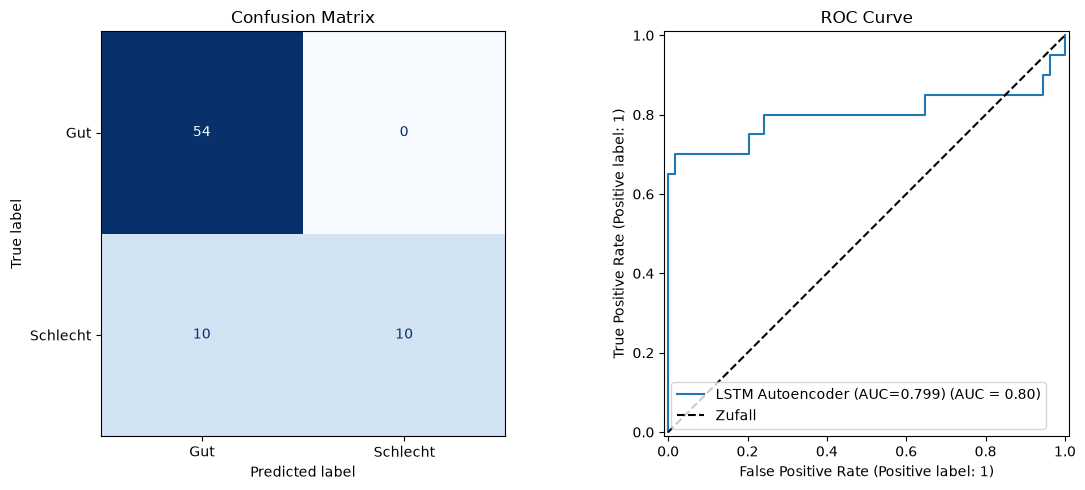

In [94]:
y_scores = np.concatenate([val_errors, bad_errors])
y_true   = np.array([0] * len(val_errors) + [1] * len(bad_errors))
y_pred   = (y_scores > threshold).astype(int)

print('=' * 50)
print('  Evaluation (Validation + Schlechte Schlaege)')
print('=' * 50)
print(classification_report(y_true, y_pred, target_names=['Gut', 'Schlecht']))

auc = roc_auc_score(y_true, y_scores)
print(f'ROC-AUC: {auc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred),
    display_labels=['Gut', 'Schlecht']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(
    y_true, y_scores,
    name=f'LSTM Autoencoder (AUC={auc:.3f})',
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Zufall')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


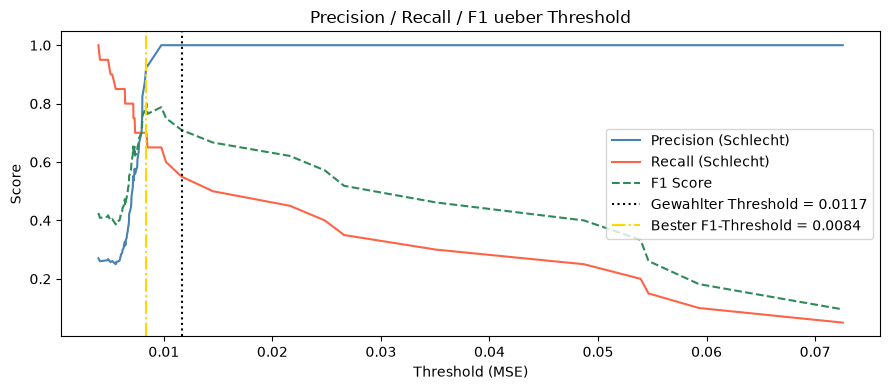

Bester F1-Score: 0.8000 bei Threshold 0.008403


In [95]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, y_scores, pos_label=1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx  = np.argmax(f1_scores)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precision[:-1], label='Precision (Schlecht)', color='steelblue')
ax.plot(thresholds, recall[:-1],    label='Recall (Schlecht)',    color='tomato')
ax.plot(thresholds, f1_scores[:-1], label='F1 Score',             color='seagreen', linestyle='--')
ax.axvline(threshold, color='black', linestyle=':',
           label=f'Gewahlter Threshold = {threshold:.4f}')
ax.axvline(thresholds[best_idx], color='gold', linestyle='-.',
           label=f'Bester F1-Threshold = {thresholds[best_idx]:.4f}')
ax.set_xlabel('Threshold (MSE)')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 ueber Threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Bester F1-Score: {f1_scores[best_idx]:.4f} bei Threshold {thresholds[best_idx]:.6f}')


## Zusammenfassung

### Ergebnisse

*(nach Ausfuehren mit Werten befuellen)*

| | Wert |
|---|---|
| **Threshold** (95. Perz.) | -- |
| **ROC-AUC** | -- |
| **Recall (Schlecht)** | -- |
| **Precision (Schlecht)** | -- |

### Einschraenkungen dieses Baselines

- **Sliding Window ignoriert Schlaggrenzen**: Ein Fenster kann ueber zwei Schlaege gehen
- **Nur ein Athlet mit schlechten Schlaegen** (cla-BAD) -- begrenzte Generalisierung

### Naechste Schritte (Ordner 3)

- Sequenzen an echten Schlaggrenzen schneiden (strokes.csv) statt Sliding Window
- Variational Autoencoder (VAE) fuer besser strukturierten Latenzraum
- Threshold automatisch optimieren (maximaler F1)
